In [1]:
# Put this in a cell BEFORE importing paddleocr / creating PaddleOCR
import os
os.environ["FLAGS_use_mkldnn"] = "0"     # disable oneDNN (MKLDNN)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # sometimes helps on Windows envs
os.environ["FLAGS_use_new_executor"] = "0"

In [2]:
# Cell 2 — Imports + paths
import os, json
from pathlib import Path
from typing import List, Dict, Any, Tuple

import cv2
from PIL import Image, ImageDraw

INPUT_PNG_DIR = Path("./data/jap_imgs")          # <-- change if needed
OUT_JSON_DIR  = Path("./outputs/ocr_json_jap")
OUT_VIS_DIR   = Path("./outputs/ocr_vis_jap")

OUT_JSON_DIR.mkdir(parents=True, exist_ok=True)
OUT_VIS_DIR.mkdir(parents=True, exist_ok=True)

png_files = sorted(INPUT_PNG_DIR.glob("*.png"))
print("Found PNGs:", len(png_files))
if png_files:
    print("Example:", png_files[0])

Found PNGs: 6
Example: data\jap_imgs\pg_1.png


In [3]:
temp = png_files[0]

In [4]:
from pathlib import Path
import json
from PIL import Image, ImageDraw

def draw_ppstructure_boxes(json_path, image_path, mode="ocr"):
    """
    mode:
      - "ocr"    -> overall_ocr_res.rec_boxes and rec_texts
      - "block"  -> parsing_res_list block_bbox
      - "layout" -> layout_det_res.boxes coordinate
      - "all"    -> draw everything with different colors
    """
    json_path = Path(json_path)
    image_path = Path(image_path)

    data = json.loads(json_path.read_text(encoding="utf-8"))
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    def draw_box(box, color, label=None):
        x1, y1, x2, y2 = [int(round(v)) for v in box]
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        if label:
            draw.text((x1, max(0, y1 - 12)), label, fill=color)

    if mode in ("block", "all"):
        for i, item in enumerate(data.get("parsing_res_list", [])):
            box = item.get("block_bbox")
            if box:
                label = f"block {i}: {item.get('block_label', '')}"
                draw_box(box, (255, 0, 0), label)

    if mode in ("layout", "all"):
        for i, item in enumerate(data.get("layout_det_res", {}).get("boxes", [])):
            box = item.get("coordinate")
            if box:
                label = f"layout {i}: {item.get('label', '')}"
                draw_box(box, (0, 128, 255), label)

    if mode in ("ocr", "all"):
        ocr = data.get("overall_ocr_res", {})
        texts = ocr.get("rec_texts", [])
        boxes = ocr.get("rec_boxes", [])
        for i, (text, box) in enumerate(zip(texts, boxes)):
            label = text.strip() if text and text.strip() else f"ocr {i}"
            draw_box(box, (0, 180, 0), label[:20])

    return image

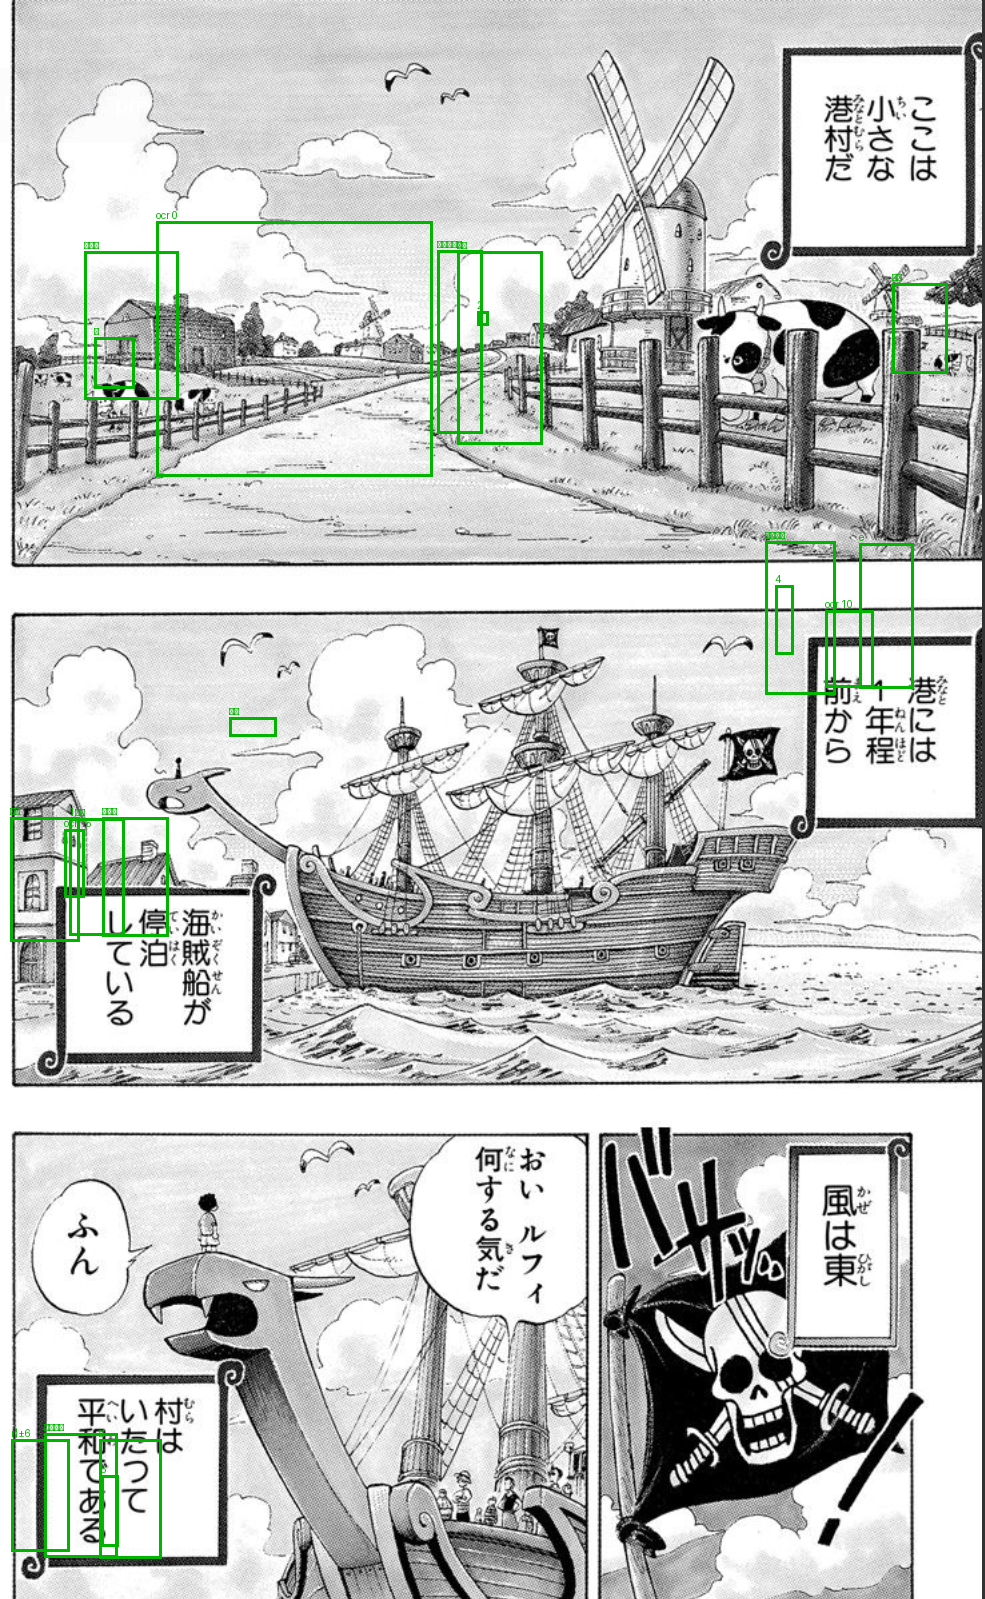

In [5]:
draw_ppstructure_boxes(
    "output/pg_1_res.json",
    "data/jap_imgs/pg_1.png",
    mode="ocr"
)

In [26]:
from transformers import AutoImageProcessor, AutoTokenizer, AutoModelForImageTextToText

processor = AutoImageProcessor.from_pretrained("kha-white/manga-ocr-base")
tokenizer = AutoTokenizer.from_pretrained("kha-white/manga-ocr-base")
model = AutoModelForImageTextToText.from_pretrained("kha-white/manga-ocr-base")

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 264/264 [00:00<00:00, 485.30it/s, Materializing param=encoder.pooler.dense.weight]                                       
The tied weights mapping and config for this model specifies to tie decoder.bert.embeddings.word_embeddings.weight to decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie decoder.cls.predictions.bias to decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update t

In [7]:
model.config.decoder_start_token_id = tokenizer.eos_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size

In [31]:
import torch
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model = model.to(device)

In [22]:
from PIL import Image
from io import BytesIO

img = Image.open(temp).convert("RGB")

In [34]:
inputs = processor(images=img, return_tensors="pt").pixel_values.to(device)

In [35]:
with torch.no_grad():
    generated_ids = model.generate(
        pixel_values=inputs,
        max_new_tokens=128
    )
generated_text = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Generated text:", generated_text)

Generated text: 個 人 情 報 の お


In [4]:
from paddleocr import PaddleOCRVL
pipeline = PaddleOCRVL(pipeline_version="v1")
output = pipeline.predict(temp)

C:\Users\abcdj\AppData\Roaming\Python\Python310\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.0.post2)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(
C:\Users\abcdj\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Creating model: ('PP-DocLayoutV2', None)
Using official model (PP-DocLayoutV2), the model files will be automatically downloaded and saved in `C:\Users\abcdj\.paddlex\official_models\PP-DocLayoutV2`.
[2026-04-07 11:08:50,128] [    INFO] _client.py:1025 - HTTP Request: GET https://huggingface.co/api/models/PaddlePaddle/PP-DocLayoutV2/revision/main "HTTP

In [10]:
pipeline.predict(str(temp))

[{'input_path': 'data\\jap_imgs\\pg_1.png',
  'page_index': None,
  'page_count': None,
  'width': 985,
  'height': 1599,
  'doc_preprocessor_res': {'output_img': array([[[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [ 51,  51,  51],
           [ 51,  51,  51],
           [ 51,  51,  51]],
   
          [[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [ 51,  51,  51],
           [ 51,  51,  51],
           [ 51,  51,  51]],
   
          [[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [ 51,  51,  51],
           [ 51,  51,  51],
           [ 51,  51,  51]],
   
          ...,
   
          [[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [ 51,  51,  51],
           [ 51,  51,  51],
           [ 51,  51,  51]],
   
          [[255, 255, 255],
           [255, 255, 255],
         

In [11]:
output = pipeline.predict(str(temp))
for res in output:
	res.print()
	res.save_to_json(save_path="output")
	res.save_to_markdown(save_path="output")

{'res': {'input_path': 'data\\jap_imgs\\pg_1.png', 'page_index': None, 'page_count': None, 'width': 985, 'height': 1599, 'model_settings': {'use_doc_preprocessor': False, 'use_layout_detection': True, 'use_chart_recognition': False, 'use_seal_recognition': False, 'use_ocr_for_image_block': False, 'format_block_content': False, 'merge_layout_blocks': True, 'markdown_ignore_labels': ['number', 'footnote', 'header', 'header_image', 'footer', 'footer_image', 'aside_text'], 'return_layout_polygon_points': True}, 'layout_det_res': {'input_path': None, 'page_index': None, 'boxes': [{'cls_id': 14, 'label': 'image', 'score': 0.9546838998794556, 'coordinate': [11, 22, 985, 565], 'order': None}, {'cls_id': 14, 'label': 'image', 'score': 0.9745681285858154, 'coordinate': [10, 611, 984, 1085], 'order': None}, {'cls_id': 14, 'label': 'image', 'score': 0.9593251943588257, 'coordinate': [13, 1130, 590, 1598], 'order': None}, {'cls_id': 14, 'label': 'image', 'score': 0.9470105171203613, 'coordinate': [

In [4]:
from paddleocr import PPStructureV3

# pipeline = PPStructureV3()
pipeline = PPStructureV3(lang="japan") # Set the lang parameter to use the English text recognition model. For other supported languages, see Section 5: Appendix. By default, both Chinese and English text recognition models are enabled.
# pipeline = PPStructureV3(use_doc_orientation_classify=True) # Use use_doc_orientation_classify to enable/disable document orientation classification model
# pipeline = PPStructureV3(use_doc_unwarping=True) # Use use_doc_unwarping to enable/disable document unwarping module
# pipeline = PPStructureV3(use_textline_orientation=True) # Use use_textline_orientation to enable/disable textline orientation classification model
# pipeline = PPStructureV3(device="gpu") # Use device to specify GPU for model inference
output = pipeline.predict(str(temp))

C:\Users\abcdj\AppData\Roaming\Python\Python310\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.0.post2)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(
C:\Users\abcdj\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `C:\Users\abcdj\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
[2026-04-07 11:35:13,800] [    INFO] _client.py:1025 - HTTP Request: GET https://huggingface.co/api/models/PaddlePaddle/PP-LCNet_x1_0

In [5]:
for res in output:
	res.print()
	res.save_to_json(save_path="output")
	res.save_to_markdown(save_path="output")

{'res': {'input_path': 'data\\jap_imgs\\pg_1.png', 'page_index': None, 'page_count': None, 'width': 985, 'height': 1599, 'model_settings': {'use_doc_preprocessor': True, 'use_seal_recognition': False, 'use_table_recognition': True, 'use_formula_recognition': True, 'use_chart_recognition': False, 'use_region_detection': True, 'format_block_content': False, 'markdown_ignore_labels': ['number', 'footnote', 'header', 'header_image', 'footer', 'footer_image', 'aside_text']}, 'parsing_res_list': [{'block_label': 'image', 'block_content': 'e \n\n海ば賊船4\n\n回问\n\nま前か\n\n1年程\n\n港は\n\n', 'block_bbox': [0, 485, 984, 991], 'block_id': 0, 'block_order': None}, {'block_label': 'text', 'block_content': '过5い小さなr}±6', 'block_bbox': [24, 1444, 150, 1550], 'block_id': 1, 'block_order': 1}], 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'model_settings': {'use_doc_orientation_classify': True, 'use_doc_unwarping': True}, 'angle': 180}, 'layout_det_res': {'input_path': None, 'page_index': N

In [3]:
from paddleocr import DocImgOrientationClassification

model = DocImgOrientationClassification(model_name="jzhang533/PaddleOCR-VL-For-Manga")
output = model.predict(temp, batch_size=1)

C:\Users\abcdj\AppData\Roaming\Python\Python310\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.0.post2)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(
C:\Users\abcdj\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


Exception: No model source is available for model `jzhang533/PaddleOCR-VL-For-Manga`! Please check model name and network, or use local model files!

In [ ]:
for res in output:
    res.print(json_format=False)
    res.save_to_img("./output/demo.png")
    res.save_to_json("./output/res.json")